# MDR-TS v15.2
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v15.2
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/base_1.0/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

New set of features


For other info see `MDR-TS-v1.0`

## 0. Imports

In [1]:
import os
import json
import math
import random
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit

# Gradient Boosting (baseline model)
from xgboost import XGBRegressor

# PyTorch
import torch

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

imports loaded
using: cpu


## 1. Environment Setup

In [2]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

# Environment / Runtime Info
def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    # Colab-specific checks
    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

# Plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 2.1.2
  Running in Colab: False
  GPU available: False
environment setup complete


## 2. Data Access

In [ ]:
# Project paths
VERSION = "v15"
SUBVERSION = "v15.2"
RUN_NAME = "mdr_ts_v15_2"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v15/v15.1

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## 3. Data Loading

In [4]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_6.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_6.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_6.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_6.0/train.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_6.0/val.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_6.0/test.csv


In [5]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 489

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'SMAP_sm_am_interp', 'SMAP_sm_pm_interp', 'soil_moisture_5cm', 'J_aspect_deg', 'J_bio_bio01', 'J_bio_bio02', 'J_bio_bio03', 'J_bio_bio04', 'J_bio_bio05', 'J_bio_bio06', 'J_bio_bio07', 'J_bio_bio08', 'J_bio_bio09', 'J_bio_bio10']


## 4. Data Sanity Checks

In [6]:
# Column definitions (baseline)
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
        "SMAP_sm_pm_interp_ema02",
        "V_rollmin_LST_modis_kobs30",
        "D_sin_DOY",
        "G_rain_sum_3d",
        "V_ema_G_API_kobs7",
        "V_rollmin_G_API_kobs30",
        "G_rain_sum_7d",
        "C_lag_LST_modis_kobs30",
        "C_lag_G_API_kobs1",
        "V_ema_G_API_kobs14",
        "V_rollmean_G_API_kobs14",
        "G_API",
        "A_pct_G_API",
        "V_rollcv_G_API_kobs30",
        "G_DSLR",
        "SMAP_ampm_diff_interp",
        "V_rollmax_G_API_kobs30",
        "V_rollmin_G_API_kobs7",
        "V_ema_G_API_kobs30",
        "V_rollmean_s2_b11_kobs7",
        "V_ema_LST_modis_kobs7",
        "C_smm_G_API_alpha0.85_n5",
        "C_lag_G_API_kobs5",
        "V_rollmean_G_API_kobs7",
        "C_lag_s2_b11_kobs30",
        "D_z_LST_modis",
        "A_d_G_API_kobs1",
        "V_rollcv_LST_modis_kobs30",
        "V_rollcv_G_API_kobs7",
        "V_rollstd_LST_modis_kobs30",
        "A_d_E_SAR_diff_kobs14",
        "C_lag_G_API_kobs6",
        "V_rollrng_F_NDMI_kobs7",
        "V_rollcv_G_API_kobs14",
        "C_lag_LST_modis_kobs6",
        "A_d_E_SAR_diff_kobs30",
        "A_d_LST_modis_kobs14",
        "SMAP_sm_am_interp_rollrange7",
        "V_rollstd_LST_modis_kobs14",
        "D_fft_ent_E_SAR_ratio_kobs30",
        "A_d_E_SAR_diff_kobs5",
        "SMAP_sm_pm_interp_rollrange7",
        "V_rollstd_F_NDMI_kobs7",
        "V_rollstd_E_SAR_ratio_kobs7",
        "V_rollrng_E_SAR_diff_kobs7",
        "V_rollstd_s2_b12_kobs7",
        "A_grad_E_SAR_diff_kobs14",
        "D_fft_dom_LST_modis_kobs30",
        "V_rollcv_s2_b12_kobs7",
        "A_d_E_SAR_ratio_kobs5",
        "D_fft_ent_LST_modis_kobs30",
        "V_rollstd_F_NDVI_kobs7",
        "A_grad_s2_b12_kobs7",
        "A_pct_F_NDVI",
        "A_d_s2_b12_kobs2",
        "A_grad_E_SAR_diff_kobs30",
        "A_d_F_NDVI_kobs2",
        "A_grad_E_SAR_diff_kobs7",
        "SMAP_sm_interp_rollrange7",
        "A_d_s2_b12_kobs7",
        "A_d_F_NDVI_kobs1",
        "V_rollcv_LST_modis_kobs14",
        "SMAP_sm_am_interp_rollstd7",
        "V_rollstd_SMAP_sm_interp_kobs7",
        "A_d_s2_b12_kobs5",
        "A_pct_SMAP_sm_interp",
        "SMAP_sm_am_interp_pctchg",
        "V_rollrng_SMAP_sm_interp_kobs7",
        "SMAP_sm_interp_pctchg",
        "A_d_E_SAR_diff_kobs2",
        "G_DSLR_isnan",
        "SMAP_sm_pm_interp_mask",
        "SMAP_sm_interp_mask",
        "SMAP_sm_am_interp_mask",
        "SMAP_sm_am_interp_diff1",
        "SMAP_sm_interp_rollstd7",
        "SMAP_sm_interp_diff1",
        "V_rollstd_E_SAR_diff_kobs7",
        "A_grad_s2_b12_kobs14",
        "A_d_E_SAR_ratio_kobs7",
        "A_grad_LST_modis_kobs14",
        "A_d_SMAP_sm_interp_kobs1",
        "SMAP_sm_pm_interp_pctchg",
        "A_grad_E_SAR_ratio_kobs7",
        "A_d_E_SAR_diff_kobs1",
        "A_d_E_SAR_diff_kobs7",
        "SMAP_sm_pm_interp_diff1",
        "A_d_F_NDVI_kobs5",
        "A_d_E_SAR_ratio_kobs2",
        "A_d_G_API_kobs5",
        "A_d_SMAP_sm_interp_kobs2",
        "D_fft_dom_E_SAR_ratio_kobs30",
        "SMAP_sm_pm_interp_rollstd7",
        "V_rollrng_s2_b12_kobs7",
        "V_rollrng_F_NDVI_kobs7",
        "A_d_SMAP_sm_interp_kobs14",
        "A_pct_E_SAR_ratio",
        "V_rollstd_SMAP_sm_interp_kobs30",
        "A_d_E_SAR_ratio_kobs1",
        "A_pct_LST_modis",
        "A_grad_SMAP_sm_interp_kobs14",
        "A_pct_E_SAR_diff",
        "SMAP_sm_interp_grad7",
        "A_grad_SMAP_sm_interp_kobs7",
        "A_d_LST_modis_kobs1",
        "V_rollcv_E_SAR_diff_kobs7",
        "A_d_s2_b11_kobs5",
        "V_rollstd_LST_modis_kobs7",
]

expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 108
  Target:   soil_moisture_5cm


In [7]:
for d in (train_df, val_df, test_df):
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

stations = sorted(set(train_df["station_id"].dropna().unique())
                  | set(val_df["station_id"].dropna().unique())
                  | set(test_df["station_id"].dropna().unique()))

print("\n=== TEMPORAL LEAKAGE CHECKS (per station) ===")
bad = 0

for sid in stations:
    tr = train_df[train_df["station_id"] == sid]["date"].dropna()
    va = val_df[val_df["station_id"] == sid]["date"].dropna()
    te = test_df[test_df["station_id"] == sid]["date"].dropna()

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print(f"[WARN] station {sid}: missing split data (train={len(tr)}, val={len(va)}, test={len(te)})")
        bad += 1
        continue

    tr_min, tr_max = tr.min(), tr.max()
    va_min, va_max = va.min(), va.max()
    te_min, te_max = te.min(), te.max()

    # date overlap checks (hard leakage)
    overlap_tr_va = len(set(tr.unique()) & set(va.unique()))
    overlap_tr_te = len(set(tr.unique()) & set(te.unique()))
    overlap_va_te = len(set(va.unique()) & set(te.unique()))

    # ordering check (soft but important)
    order_ok = (tr_max < va_min) and (va_max < te_min)

    if overlap_tr_va or overlap_tr_te or overlap_va_te or (not order_ok):
        print(f"[ERROR] station {sid}:")
        print(f"  train: {tr_min} -> {tr_max}")
        print(f"  val:   {va_min} -> {va_max}")
        print(f"  test:  {te_min} -> {te_max}")
        print(f"  overlaps: train∩val={overlap_tr_va}, train∩test={overlap_tr_te}, val∩test={overlap_va_te}")
        print(f"  order_ok: {order_ok}")
        bad += 1
    else:
        print(f"[OK] station {sid}: train<{val_df is not None and 'val' or ''}val<test with no date overlap")

if bad == 0:
    print("\n[INFO] No temporal leakage detected.")
else:
    print(f"\n[WARNING] {bad} station(s) have temporal leakage or split issues.")



=== TEMPORAL LEAKAGE CHECKS (per station) ===
[OK] station Darrington: train<valval<test with no date overlap
[OK] station Quinault: train<valval<test with no date overlap
[OK] station SourdoughGulch_WA_985: train<valval<test with no date overlap
[OK] station Spokane: train<valval<test with no date overlap
[WARN] station Touchet_WA_824: missing split data (train=3311, val=0, test=170)

[WARNING] 1 station(s) have temporal leakage or split issues.


In [8]:
print("\nTemporal split check (train -> validation):")

for sid in sorted(train_df["station_id"].unique()):
    train_dates = train_df.loc[train_df["station_id"] == sid, "date"]
    val_dates   = val_df.loc[val_df["station_id"] == sid, "date"]

    max_train = train_dates.max()
    min_val   = val_dates.min()

    print(f"  Station {sid}:")
    print(f"    train max date: {max_train}")
    print(f"    val   min date: {min_val}")


Temporal split check (train -> validation):
  Station Darrington:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Quinault:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station SourdoughGulch_WA_985:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Spokane:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Touchet_WA_824:
    train max date: 2020-10-28 00:00:00
    val   min date: NaT


## 5. Train / Validation / Test Split

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [9]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     16972
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2011-10-06 00:00:00 -- 2021-09-23 00:00:00

VAL
  rows:     2919
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-09-24 00:00:00 -- 2023-11-12 00:00:00

TEST
  rows:     2829
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-11-13 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


## 6. Model Definition

This section defines the MDR-TS v1.0 baseline model.
The emphasis here is **transparency and debuggability**, not maximal performance.

The model is intentionally simple and interpretable:
- Explicit feature matrices
- No feature embedding or deep architecture
- Full access to feature importance and diagnostics

This serves as a reference point for all future MDR models.

### 6.1 Feature Matrix Construction

In [10]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()

X_val = val_df[FEATURE_COLS].copy()
y_val = val_df[TARGET_COL].copy()

X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].copy()

print("Feature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")

Feature matrix shapes:
  X_train: (16972, 108)
  X_val:   (2919, 108)
  X_test:  (2829, 108)
  y_train: (16972,)


### 6.2 Feature Overview

In [11]:
feature_summary = pd.DataFrame({
    "mean": X_train.mean(),
    "std": X_train.std(),
    "min": X_train.min(),
    "max": X_train.max(),
}).sort_values("std", ascending=False)

feature_summary # interactive sheet

,mean,std,min,max
A_pct_G_API,76.666423,9980.235936,-0.100000,1.300000e+06
C_smm_G_API_alpha0.85_n5,135.545656,157.525647,0.000000,1.168583e+03
V_rollmax_G_API_kobs30,74.219122,72.224672,0.225530,4.087574e+02
C_lag_G_API_kobs1,43.039290,50.742830,0.000000,4.087574e+02
G_API,43.040359,50.740737,0.000000,4.087574e+02
...,...,...,...,...
V_rollstd_E_SAR_diff_kobs7,0.001309,0.003050,0.000000,4.728213e-02
A_grad_SMAP_sm_interp_kobs14,-0.000013,0.002882,-0.014076,1.960790e-02
A_grad_E_SAR_diff_kobs7,0.000005,0.001162,-0.013485,1.495192e-02
A_grad_E_SAR_diff_kobs14,0.000005,0.000749,-0.009747,7.147361e-03


### 6.4 Baseline Model Definition

In [16]:
DEEP_SEARCH = 40

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

In [13]:
XGB_PARAMS = dict(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,

    subsample=0.9,
    reg_lambda=2.0,
    reg_alpha=0.05,
    n_estimators=4000,
    min_child_weight=3,
    max_depth=7,
    learning_rate=0.05,
    gamma=0.0,
    colsample_bytree=0.75,
)

model_xgb = XGBRegressor(**XGB_PARAMS)

MODEL_CONFIG_FINAL = model_xgb.get_params()

print("\nUsing fixed XGB params:")
for k in [
    "n_estimators","max_depth","learning_rate","min_child_weight","gamma",
    "subsample","colsample_bytree","reg_alpha","reg_lambda"
]:
    print(f"  {k}: {MODEL_CONFIG_FINAL.get(k)}")


Using fixed XGB params:
  n_estimators: 4000
  max_depth: 7
  learning_rate: 0.05
  min_child_weight: 3
  gamma: 0.0
  subsample: 0.9
  colsample_bytree: 0.75
  reg_alpha: 0.05
  reg_lambda: 2.0


In [17]:
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=1000,
)

yhat_train = model_xgb.predict(X_train)
yhat_val   = model_xgb.predict(X_val)
yhat_test  = model_xgb.predict(X_test)

print("\nXGB predictions generated")
print("  yhat_train:", yhat_train.shape)
print("  yhat_val:  ", yhat_val.shape)
print("  yhat_test: ", yhat_test.shape)

print("\nRMSE")
print("  train:", rmse(y_train, yhat_train))
print("  val:  ", rmse(y_val,   yhat_val))
print("  test: ", rmse(y_test,  yhat_test))

[0]	validation_0-rmse:0.09810	validation_1-rmse:0.10003
[1000]	validation_0-rmse:0.00446	validation_1-rmse:0.04050
[2000]	validation_0-rmse:0.00243	validation_1-rmse:0.04042
[3000]	validation_0-rmse:0.00190	validation_1-rmse:0.04041
[3999]	validation_0-rmse:0.00173	validation_1-rmse:0.04040

XGB predictions generated
  yhat_train: (16972,)
  yhat_val:   (2919,)
  yhat_test:  (2829,)

RMSE
  train: 0.0017269114202029272
  val:   0.04040250434662976
  test:  0.04847064766160411


## 7. Training Loop

In [18]:
RF_PARAMS = dict(
    n_estimators=1600,
    min_samples_split=20,
    min_samples_leaf=2,
    max_features="sqrt",
    max_depth=None,
    n_jobs=-1,
    random_state=SEED,
    bootstrap=True,
)

model_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(**RF_PARAMS)),
])

MODEL_CONFIG_RF = {
    "n_estimators": model_rf.named_steps["model"].n_estimators,
    "max_depth": model_rf.named_steps["model"].max_depth,
    "min_samples_leaf": model_rf.named_steps["model"].min_samples_leaf,
    "min_samples_split": model_rf.named_steps["model"].min_samples_split,
    "max_features": model_rf.named_steps["model"].max_features,
    "n_jobs": model_rf.named_steps["model"].n_jobs,
    "random_state": model_rf.named_steps["model"].random_state,
    "bootstrap": model_rf.named_steps["model"].bootstrap,
}

print("\nUsing fixed RF params:")
for k, v in MODEL_CONFIG_RF.items():
    print(f"  {k}: {v}")


Using fixed RF params:
  n_estimators: 1600
  max_depth: None
  min_samples_leaf: 2
  min_samples_split: 20
  max_features: sqrt
  n_jobs: -1
  random_state: 42
  bootstrap: True


In [19]:
model_rf.fit(X_train, y_train)

yhat_train_rf = model_rf.predict(X_train)
yhat_val_rf   = model_rf.predict(X_val)
yhat_test_rf  = model_rf.predict(X_test)

print("\nRF predictions generated")
print("  yhat_train_rf:", yhat_train_rf.shape)
print("  yhat_val_rf:  ", yhat_val_rf.shape)
print("  yhat_test_rf: ", yhat_test_rf.shape)

print("\nRMSE")
print("  train:", rmse(y_train, yhat_train_rf))
print("  val:  ", rmse(y_val,   yhat_val_rf))
print("  test: ", rmse(y_test,  yhat_test_rf))


RF predictions generated
  yhat_train_rf: (16972,)
  yhat_val_rf:   (2919,)
  yhat_test_rf:  (2829,)

RMSE
  train: 0.01755256699183563
  val:   0.0395998019451833
  test:  0.04575991321425719


In [25]:
yhat_train_np = np.asarray(yhat_train).ravel()
yhat_val_np   = np.asarray(yhat_val).ravel()
yhat_test_np  = np.asarray(yhat_test).ravel()

y_train_np = np.asarray(y_train).ravel()
y_val_np   = np.asarray(y_val).ravel()
y_test_np  = np.asarray(y_test).ravel()

print("Base XGB test R2:", float(r2_score(y_test_np, yhat_test_np)))
print("Base XGB val  R2:", float(r2_score(y_val_np,  yhat_val_np)))
print("Base XGB test bias (true-pred):", float(np.mean(y_test_np - yhat_test_np)))

Base XGB test R2: 0.731427707371975
Base XGB val  R2: 0.8390831835977752
Base XGB test bias (true-pred): 0.01601690110816272


In [27]:
yhat_train_rf_np = np.asarray(yhat_train_rf).ravel()
yhat_val_rf_np   = np.asarray(yhat_val_rf).ravel()
yhat_test_rf_np  = np.asarray(yhat_test_rf).ravel()

print("Base RF test R2:", float(r2_score(y_test_np, yhat_test_rf_np)))
print("Base RF val  R2:", float(r2_score(y_val_np,  yhat_val_rf_np)))
print("Base RF test bias (true - pred):", float(np.mean(y_test_np - yhat_test_rf_np)))

Base RF test R2: 0.760627671085639
Base RF val  R2: 0.8454137406883704
Base RF test bias (true - pred): 0.013994202593211826


In [28]:
alphas = np.logspace(-6, 3, 15)
best = None

for a in alphas:
    cal_tmp = Ridge(alpha=a)
    cal_tmp.fit(yhat_val_np.reshape(-1, 1), y_val_np)
    yhat_val_cal_tmp = cal_tmp.predict(yhat_val_np.reshape(-1, 1))
    r2_val = r2_score(y_val_np, yhat_val_cal_tmp)

    if (best is None) or (r2_val > best["r2_val"]):
        best = {
            "alpha": a,
            "r2_val": float(r2_val),
            "slope": float(cal_tmp.coef_[0]),
            "intercept": float(cal_tmp.intercept_),
        }

print("Best Ridge (selected on VAL):")
print("  alpha     =", best["alpha"])
print("  slope a   =", best["slope"])
print("  intercept =", best["intercept"])
print("  val R2    =", best["r2_val"])
print()

Best Ridge (selected on VAL):
  alpha     = 1e-06
  slope a   = 0.9763249754905701
  intercept = 0.022765502333641052
  val R2    = 0.8714220722215795



In [29]:
cal = Ridge(alpha=best["alpha"])
cal.fit(yhat_val_np.reshape(-1, 1), y_val_np)

yhat_train_cal = cal.predict(yhat_train_np.reshape(-1, 1))
yhat_val_cal   = cal.predict(yhat_val_np.reshape(-1, 1))
yhat_test_cal  = cal.predict(yhat_test_np.reshape(-1, 1))

### 7.2 Metrics

In [30]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

def metrics_block(name, y_true, y_pred):
    return {
        "split": name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
        "bias_mean(true-pred)": float(np.mean(y_true - y_pred)),
    }

results_before = pd.DataFrame([
    metrics_block("train", y_train_np, yhat_train_np),
    metrics_block("val",   y_val_np,   yhat_val_np),
    metrics_block("test",  y_test_np,  yhat_test_np),
])

results_after = pd.DataFrame([
    metrics_block("train", y_train_np, yhat_train_cal),
    metrics_block("val",   y_val_np,   yhat_val_cal),
    metrics_block("test",  y_test_np,  yhat_test_cal),
])

print("BEFORE:")
display(results_before)

print("\nAFTER (Ridge post-hoc calibrated):")
display(results_after)


BEFORE:


,split,MAE,RMSE,R2,bias_mean(true-pred)
0,train,0.001182,0.001727,0.999715,-0.000003
1,val,0.030309,0.040403,0.839083,0.017968
2,test,0.037712,0.048471,0.731428,0.016017



AFTER (Ridge post-hoc calibrated):


,split,MAE,RMSE,R2,bias_mean(true-pred)
0,train,0.018155,0.018412,0.967579,-1.815445e-02
1,val,0.027748,0.036115,0.871422,-5.735329e-09
2,test,0.036667,0.045751,0.760723,-2.001251e-03


In [31]:
meta_val  = np.column_stack([yhat_val_np,  np.asarray(yhat_val_rf).ravel()])
meta_test = np.column_stack([yhat_test_np, np.asarray(yhat_test_rf).ravel()])

meta = Ridge(alpha=1.0)
meta.fit(meta_val, y_val_np)

yhat_test_stack = meta.predict(meta_test)

print("STACKED (XGB+RF -> Ridge) test metrics:")
print("  R2  :", float(r2_score(y_test_np, yhat_test_stack)))
print("  MAE :", float(mean_absolute_error(y_test_np, yhat_test_stack)))
print("  RMSE:", rmse(y_test_np, yhat_test_stack))
print("  bias:", float(np.mean(y_test_np - yhat_test_stack)))
print("  weights:", meta.coef_, "intercept:", float(meta.intercept_))

STACKED (XGB+RF -> Ridge) test metrics:
  R2  : 0.7811774070765262
  MAE : 0.03452688247056053
  RMSE: 0.04375163623049726
  bias: -0.0024781043355433076
  weights: [0.48046833 0.53280584] intercept: 0.014755543503387564


In [32]:
meta_val2  = np.column_stack([yhat_val_cal,  np.asarray(yhat_val_rf).ravel()])
meta_test2 = np.column_stack([yhat_test_cal, np.asarray(yhat_test_rf).ravel()])

meta2 = Ridge(alpha=1.0)
meta2.fit(meta_val2, y_val_np)

yhat_test_stack2 = meta2.predict(meta_test2)

print("\nSTACKED using calibrated XGB preds:")
print("  R2  :", float(r2_score(y_test_np, yhat_test_stack2)))
print("  MAE :", float(mean_absolute_error(y_test_np, yhat_test_stack2)))
print("  RMSE:", rmse(y_test_np, yhat_test_stack2))
print("  bias:", float(np.mean(y_test_np - yhat_test_stack2)))
print("  weights:", meta2.coef_, "intercept:", float(meta2.intercept_))


STACKED using calibrated XGB preds:
  R2  : 0.7813686350582895
  MAE : 0.03450504191590182
  RMSE: 0.04373251488280786
  bias: -0.0024863075364063973
  weights: [0.48371241 0.54133626] intercept: 0.003669849673264336


### 7.3 Diagnostics

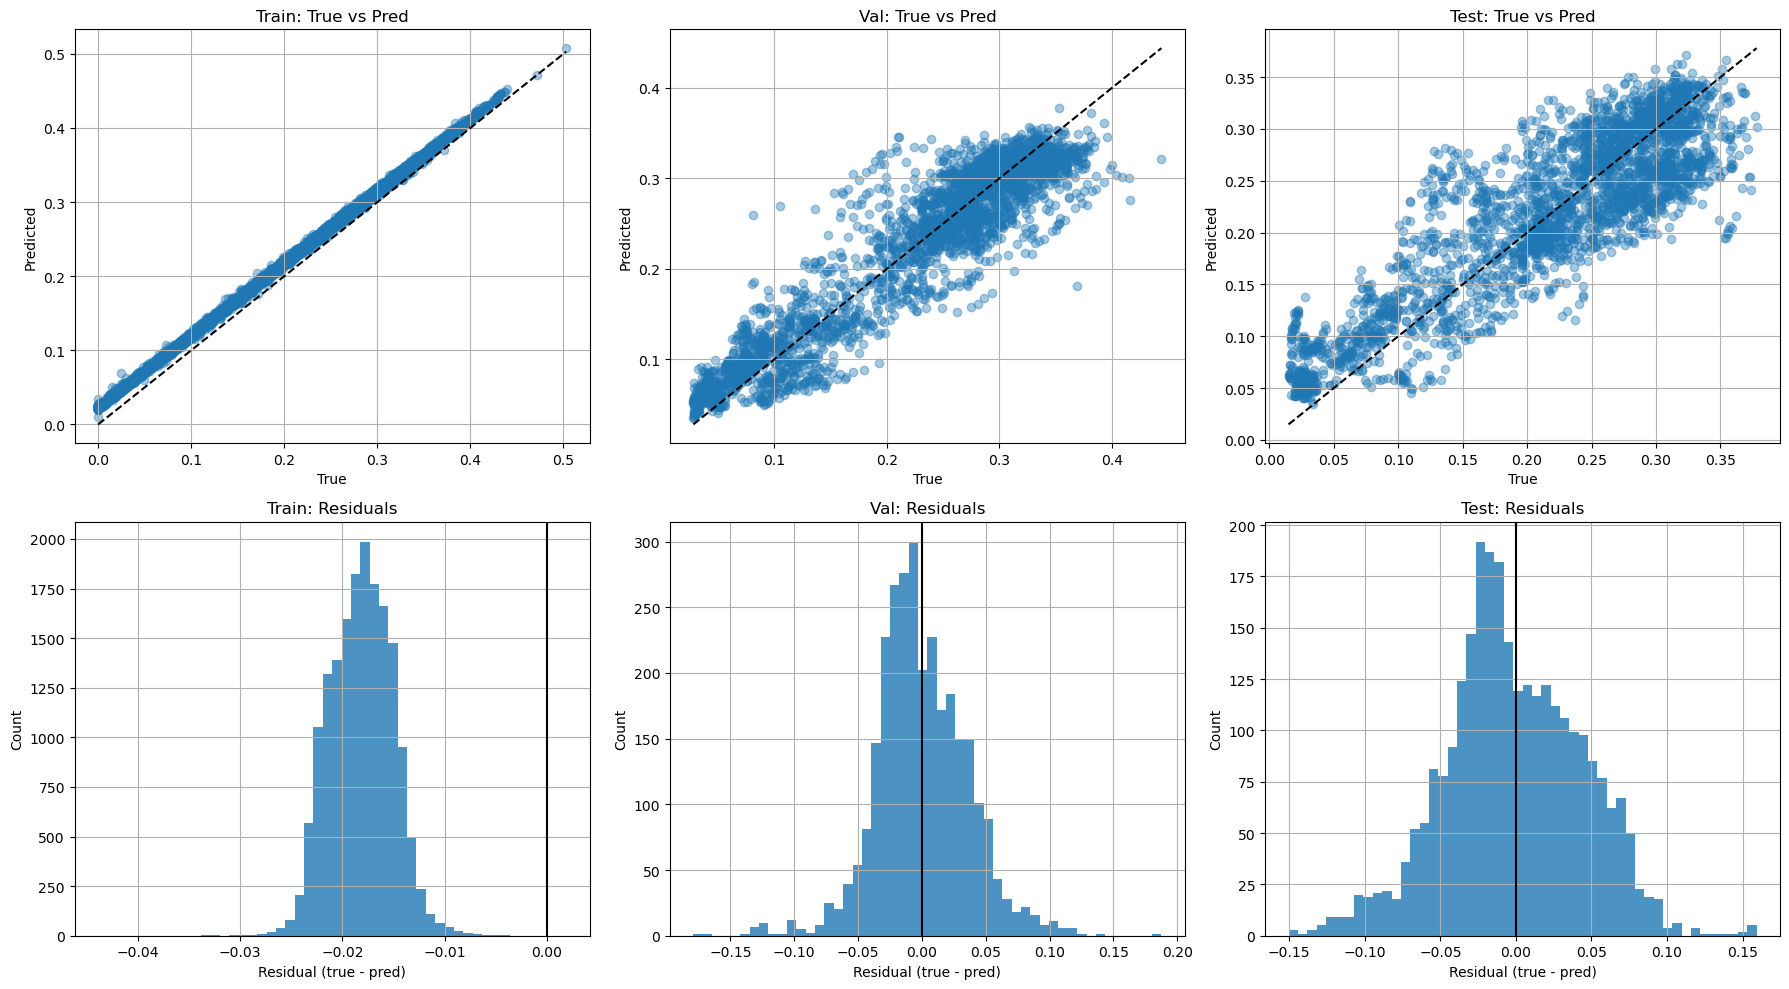

In [33]:
def scatter_plot(ax, y_true, y_pred, title):
    ax.scatter(y_true, y_pred, alpha=0.4)
    ax.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color="black",
        linestyle="--",
    )
    ax.set_title(title)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.grid(True)


def residual_hist(ax, y_true, y_pred, title):
    resid = y_true.values - y_pred
    ax.hist(resid, bins=50, alpha=0.8)
    ax.axvline(0, color="black")
    ax.set_title(title)
    ax.set_xlabel("Residual (true - pred)")
    ax.set_ylabel("Count")
    ax.grid(True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

scatter_plot(axes[0, 0], y_train, yhat_train_cal, "Train: True vs Pred")
scatter_plot(axes[0, 1], y_val,   yhat_val_cal,   "Val: True vs Pred")
scatter_plot(axes[0, 2], y_test,  yhat_test_cal,  "Test: True vs Pred")

residual_hist(axes[1, 0], y_train, yhat_train_cal, "Train: Residuals")
residual_hist(axes[1, 1], y_val,   yhat_val_cal,   "Val: Residuals")
residual_hist(axes[1, 2], y_test,  yhat_test_cal,  "Test: Residuals")

plt.tight_layout()
plt.show()

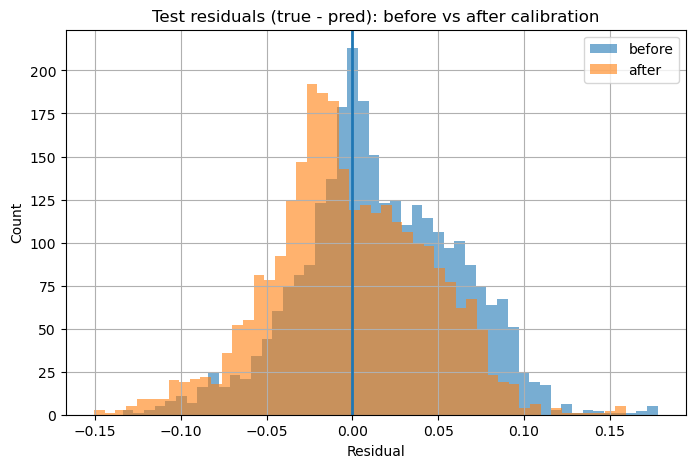

In [34]:
res_before = y_test - yhat_test
res_after  = y_test - yhat_test_cal

plt.figure()
plt.hist(res_before, bins=50, alpha=0.6, label="before")
plt.hist(res_after,  bins=50, alpha=0.6, label="after")
plt.axvline(0, linewidth=2)
plt.title("Test residuals (true - pred): before vs after calibration")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.legend()
plt.show()

### 7.4 Feature Importance

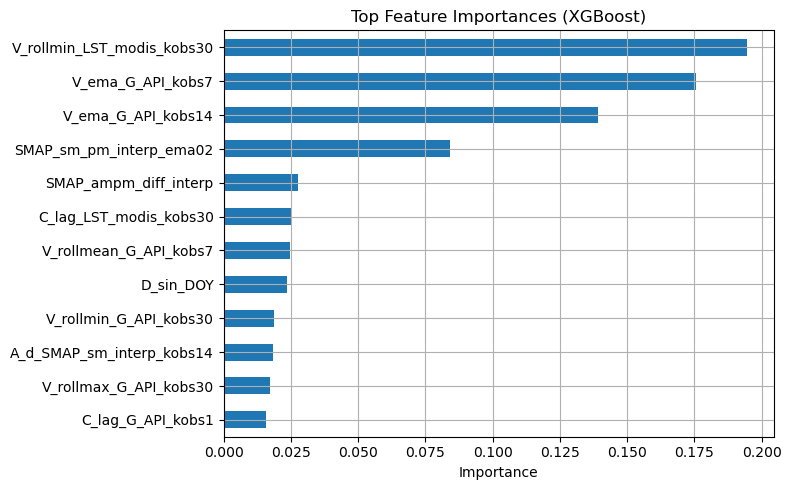

V_rollmin_LST_modis_kobs30    0.194749
V_ema_G_API_kobs7             0.175476
V_ema_G_API_kobs14            0.139109
SMAP_sm_pm_interp_ema02       0.084089
SMAP_ampm_diff_interp         0.027722
                                ...   
A_d_SMAP_sm_interp_kobs1      0.000013
SMAP_sm_pm_interp_mask        0.000008
G_DSLR_isnan                  0.000000
SMAP_sm_interp_mask           0.000000
SMAP_sm_am_interp_mask        0.000000
Length: 108, dtype: float32

In [30]:
importances = pd.Series(model_xgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(12).sort_values().plot(kind="barh")
plt.title("Top Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

## 8. Evaluation

### 8.1 Test Metrics

In [31]:
test_metrics = {
    "MAE":  mean_absolute_error(y_test, yhat_test_cal),
    "RMSE": rmse(y_test, yhat_test_cal),
    "R2":   r2_score(y_test, yhat_test_cal),
    "n":    len(y_test),
}

pd.DataFrame([test_metrics])

,MAE,RMSE,R2,n
0,0.036667,0.045751,0.760723,2829


### 8.2 Test Prediction Scatter

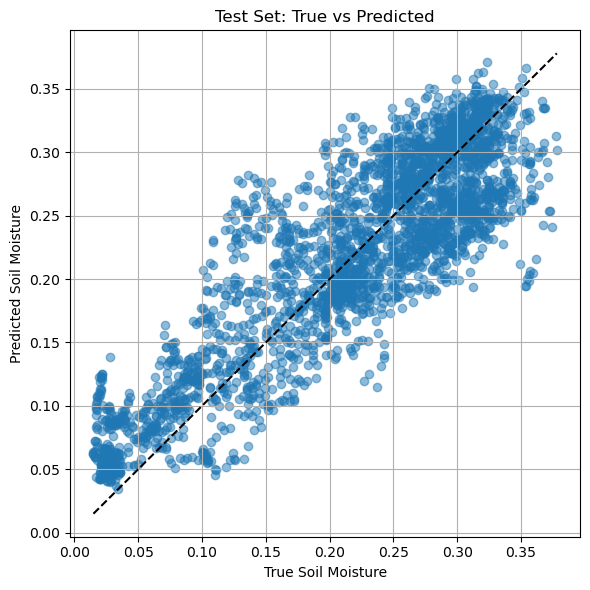

In [32]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, yhat_test_cal, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="black", linestyle="--")
plt.xlabel("True Soil Moisture")
plt.ylabel("Predicted Soil Moisture")
plt.title("Test Set: True vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

### 8.3 Bias

In [33]:
print(
    f"""
Residual diagnostics
--------------------
VAL  residual mean : {float((y_val.values - yhat_val_cal).mean()): .6f}
TEST residual mean : {float((y_test.values - yhat_test_cal).mean()): .6f}

Prediction ranges
-----------------
VAL  range : {float(yhat_val_cal.min()): .6f} to {float(yhat_val_cal.max()): .6f}
TEST range : {float(yhat_test_cal.min()): .6f} to {float(yhat_test_cal.max()): .6f}
"""
)


Residual diagnostics
--------------------
VAL  residual mean : -0.000000
TEST residual mean : -0.002001

Prediction ranges
-----------------
VAL  range :  0.035141 to  0.377429
TEST range :  0.034404 to  0.371025



---

_Jakob Balkovec_